In [5]:
import sys; sys.path.insert(0, '.')
from python.bugs_py import Bugs, plot_egenome_orbit_sweep
from python.bugs_py import plot_food_power_spectrum
from python.bugs_py import plot_egenome
from python.controls import available_probes

from python.controls import run_with_controls
import time
import numpy as np
from pprint import pprint
from matplotlib import pyplot as plt

In [7]:
pprint(available_probes())

{'G-activity': 'G-activity: whole-genome content-hash strip chart',
 'Gq-activity': 'Gq-activity: G-activity deciles',
 'coloring': 'Bug-coloring: per-LUT-index move distribution (3x3 template)',
 'egenome': 'Egenome: 9-position strip chart of per-position quantiles',
 'g-activity': 'g-activity: per (nbhd, move) LUT-slot strip chart',
 'gq-activity': 'gq-activity: g-activity deciles',
 'ts': 'Scalar time-series (population, total food-in-bugs)'}


# Bugs

We begin with the Bugs model [1,2],  It consists of a population of sensory-motor agents (bugs) on a 2d lattice.  The lattice is also populated with a food field, which the bugs eat.  Each bug has a brain, consisting of an LUT.  LUT inputs are gathered from the food field in the bug's Moore neighborhood (9 cells), with the food field thresholded to produce one bit per cell of the neighborhood, yielding a 9-bit address into the LUT.  The output of the LUT is a movement vector. In this work the space of possible movement vectors will be the set of 8 possible displacements from the center cell of the Moore neighborhood.  The bug eats until it's internal food supply exceeds a reproductive threshold, at which point the bug reproduces, creating a copy of itself with the possibility of mutation of the LUT by changing an output vector to a random new one.  Thus, the LUT may be considered to be not only the bug's brain, but also the bug's genome, which is possibly mutated during reproduction.  

A bug's dynamics is to
- eat a mouthful of food from the food field at the bug's current site.
- if the bug's food exceeds the reproductive threshold, it reproduces with mutation.
- perceive the food in the neighborhood, and look up consequent movement.
- move to the new location specified by the LUT

The population dynamics is to repeat the sequence above for every bug in the population.  The population evolves as the bug genomes are mutated.  We expect the population to evolve toward bugs that become increasingly proficient at finding and eating food.  The bugs' evolution is strongly affected by any spatial structure that might emerge in the food field. as a result of the bugs' activity.

1. Packard, N. 1989. Intrinsic Adaptation in a Simple Model for Evolution. In Langton, C. (ed.) Artificial Life (Redwood City, CA: Addison-Wesley) (1989), 141-155.

2. Bedau, M. A., and Packard, N. H. 1992. Measurement of Evolutionary Activity, Teleology, and Life. In Langton, C., Taylor, C., Farmer, J. D., and Rasmussen, S., (eds.) 1992. Artificial Life II (Redwood City, CA: Addison Wesley), 431-461.

# EvoPerception

This notebook explores evolution of bug perception.  The bugs described above have a perceptual mechanism consisting of gathering bits from a bug's Moore neighborhood by thresholding the food field.  The threshold value is normally a global meta-parameter of the model.  In the present version of the model, we consider a finer grain process for perceiving food, with each bug having the possibility of perceiving food with a separate threshold for each cell in its Moore neighborhood.  This requires the specification of 9 numbers for each bug, which we will call the e-genome:
`[eNW,eN,eNE,eW,eC,eE,eSW,eS,eSE]`:  
|  | W | C | E |
| :---: | :---: | :---: | :---: |
| N | eNW | eN | eNE|
| C | eW | eC | eE |
| S | eSW | eS | eSE |

Each entry in the vector has a number that specifies a food threshold (with a value between 0 and 1, the limits of the food field values) that translates the food field's configuration into a bit of the bug's LUT genome that specifies its movement.

We inerpret the e-genome thresholds as a perceptual apparatus for the bug.  If all entries are zero (or all 1), the bug is blind, only one entry of its LUT is ever accessed.  We will explore evolution of a population of bugs that is initialized with relatively blind bugs, expecting them to evolve more complex perception.

$\mu_\text{e-genome}$ specifies mutation of the e-genomes at each birth event.  It is a number $0 \le \mu_\text{e-genome} < 1$ that determines the width of the Gaussian distribution from which mutations of the e-genome entries are drawn.


## Evolution from constant e-genome, uniform food

For this section, we have
```
egenome_initial = [0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1]
food_source='uniform'
food_source_value=1.0
```

we will begin with the rate food is replenished
```
food_inc=0.01
```
but consider variations on this, below.


In [2]:
sim = Bugs()
sim.init(256, 
         food_inc=0.02, 
         mutation_rate=0.1,
         mu_egenome = 0.8,
         move_range=1)
sim.state(food_source='uniform', food_source_value=1.0, seed_density=0.2)

run_with_controls(
    sim, cell_px=3,
    probes={'G-activity': True, 'Gq-activity': True,
            'ts': True,
            'egenome': True
            }
)

[controls] mu_egenome=0.8 is outside the slider range [0.0, 0.1]; clamping to 0.1.


<Thread(bugs-sim, started daemon 6346223616)>

In [4]:
actx = sim.activity_crossings()
len(actx)

240

In [7]:
(min(actx),max(actx))

(np.float32(1.0), np.float32(10.0))

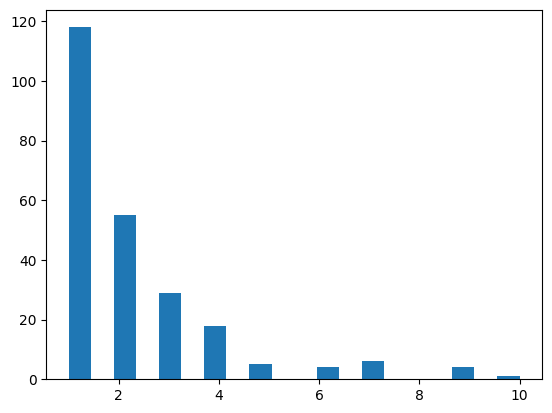

In [5]:
plt.hist(actx,bins=20);

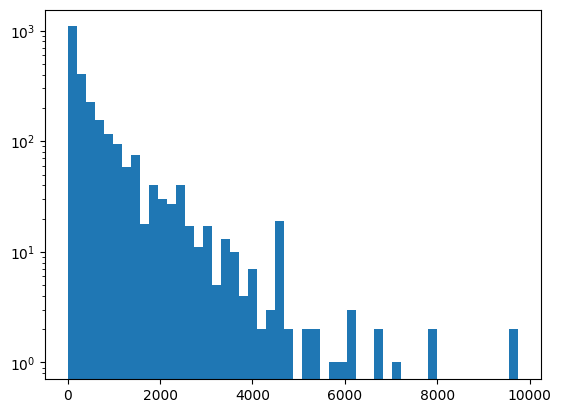

In [4]:
age=sim.get_ages()
plt.hist(age,bins=50,log=True);

In [3]:
foo = sim.get_egenome()
foo.shape

(2451, 9)

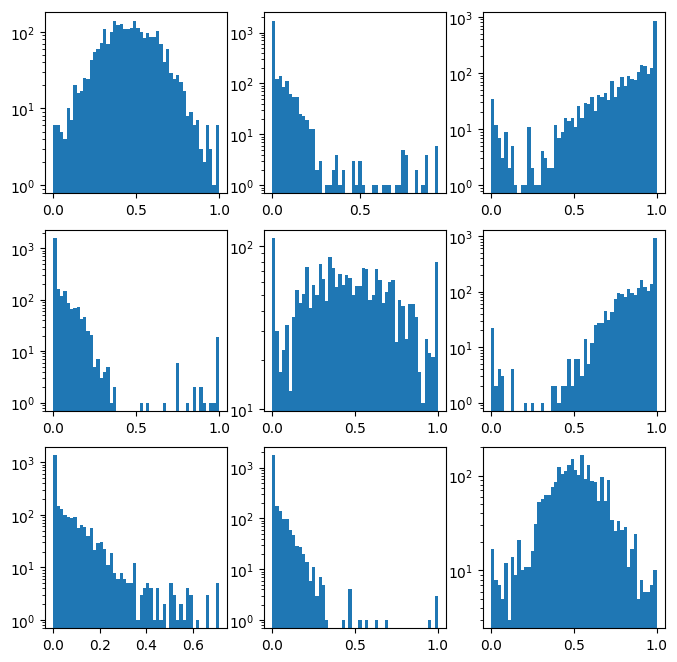

In [3]:
foo = sim.get_egenome()
fig,ax = plt.subplots(3,3,figsize=(8,8))
axx = ax.flat
for i in range(9):
    axx[i].hist(foo[:,i],bins=50,log=True);

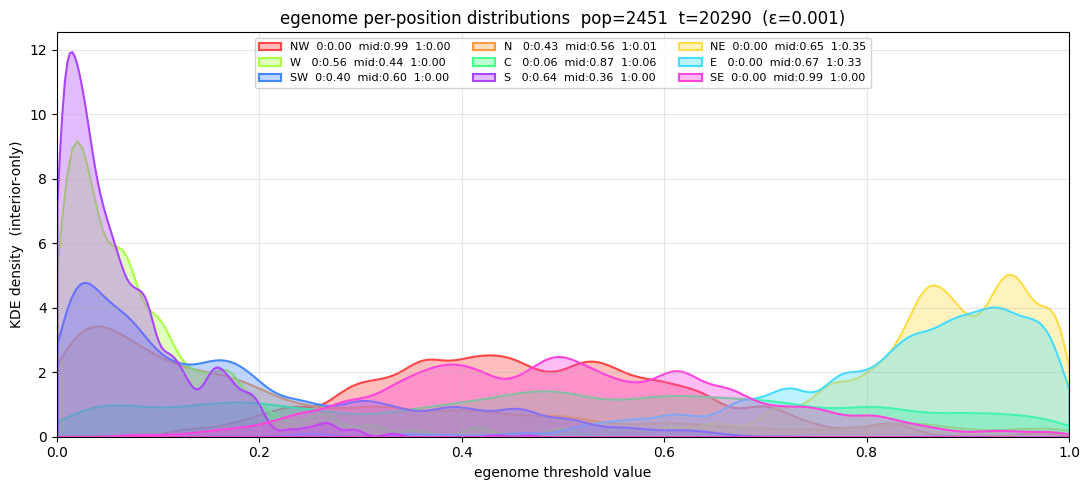

In [5]:
plot_egenome(sim);

In [55]:
fofo = foo[:1000,:2]
fofo[:10,:]

array([[0.475827  , 0.22002739],
       [0.38317403, 0.01213576],
       [0.3230798 , 0.        ],
       [0.08427375, 0.12420287],
       [0.28342968, 0.        ],
       [0.        , 0.        ],
       [0.        , 0.        ],
       [0.44276258, 0.07793669],
       [0.51116025, 0.13819909],
       [0.10726466, 0.13827464]], dtype=float32)

In [50]:
fofo = [0,0,0]
all([x==fofo[0] for x in fofo])

True

In [51]:
fofo = [x for x in foo[:,] if all([y==x[0] for y in x])==True]

In [52]:
len(fofo)

1

In [23]:
foo = sim.params()

# Diag

[0.19831061 0.24059103 0.18710764 0.23462033 0.3321119  0.14542243
 0.25407135 0.3601019  0.18842296]
[0.7351958  0.3713731  0.67646897 0.5952151  0.39423484 0.02135235]


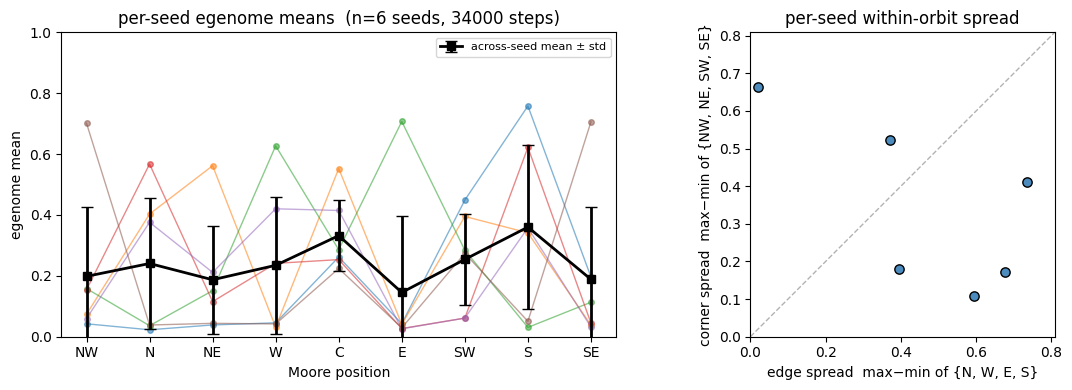

In [25]:
fig, info = plot_egenome_orbit_sweep(
  init=foo,
  state={'food_source': 'uniform', 'food_source_value': 1.0, 'seed_density': 0.2},
  seeds=range(6), steps=34000,
)
print(info['across_mean'])    # flat within orbits → isotropic
print(info['edge_spread'])    # per-seed asymmetry distribution

In [16]:
import seaborn as sns

In [ ]:
sns.kde

0.07719040415554992


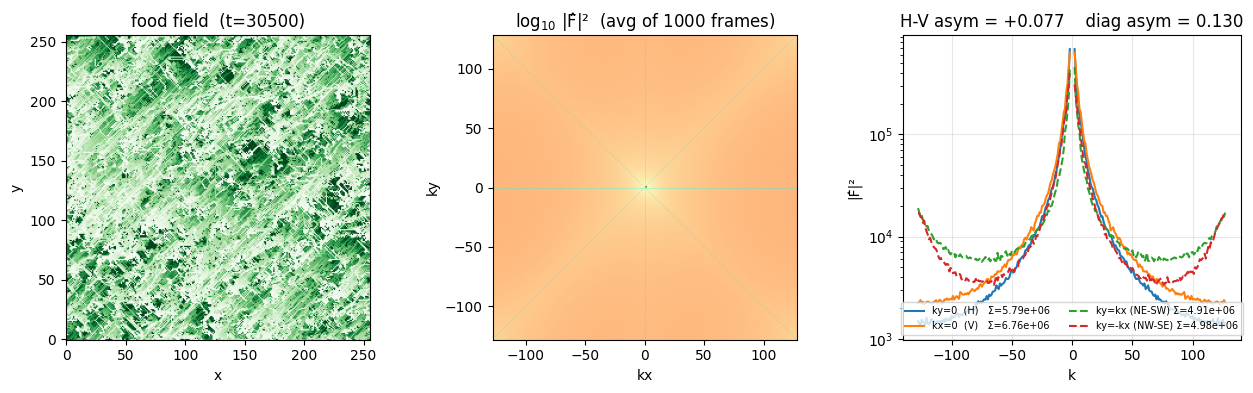

In [4]:
fig, info = plot_food_power_spectrum(sim,1000,10);
print(info['asymmetry'])

In [7]:
[(x,info[x]) for x in info if 'asym' in x]

[('asymmetry', 0.07719040415554992),
 ('asymmetry_diag', 0.006980050219042135),
 ('diag_asym', 0.12987438115781524)]

In [7]:
np.abs(-1)

np.int64(1)

In [11]:
Pdiag = info['P_ne_sw']
Pdiagg = info['P_nw_se']
np.abs(Pdiag-Pdiagg)/(Pdiag+Pdiag)

np.float64(0.08800324270005815)

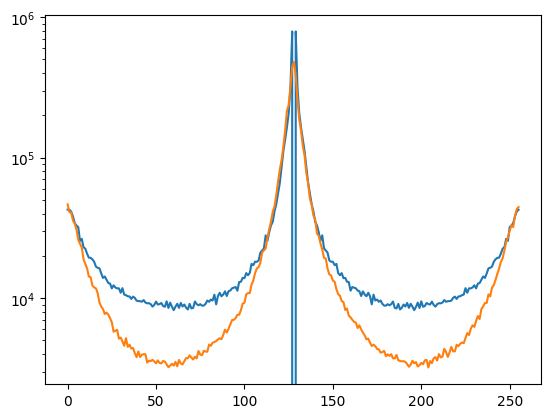

In [14]:
P=info['P_mean_2d']
ne_sw_axis = np.diag(P).copy()                 # length N
nw_se_axis = np.diag(np.fliplr(P)).copy()      # length N

plt.semilogy(ne_sw_axis)
plt.semilogy(nw_se_axis);


In [15]:
P_ne_sw = float(ne_sw_axis.sum())
P_nw_se = float(nw_se_axis.sum())
denom_d = P_ne_sw + P_nw_se
asym_diag = (P_ne_sw - P_nw_se) / denom_d if denom_d > 0 else 0.0
asym_diag

0.09649512675966151

In [16]:
(P_ne_sw, P_nw_se)

(7388225.213995066, 6087849.660735272)

In [18]:
min(nw_se_axis)

np.float64(3210.3136246028794)

In [17]:
min(ne_sw_axis)

np.float64(0.0)

In [22]:
P=info['P_mean_2d']
ne_sw_axis = np.diag(P).copy()                 # length N
nw_se_axis = np.diag(np.fliplr(P)).copy()      # length N
diffs = [x-y for x,y in zip(ne_sw_axis,nw_se_axis)]
sums = [x+y for x,y in zip(ne_sw_axis,nw_se_axis)]


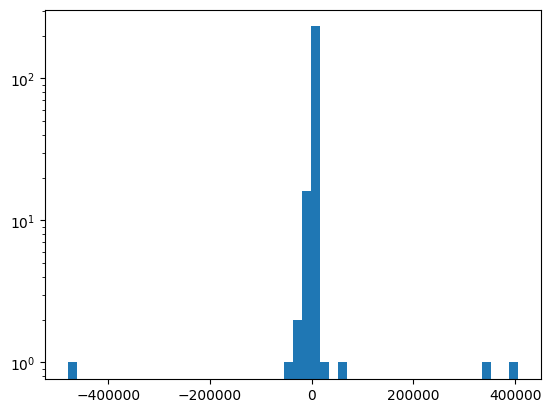

In [29]:
plt.hist(diffs,bins=50,log=True);
#plt.xlim([-100000,100000])

In [19]:
sim.step_display(200, delay=0.02)

In [4]:
for _ in range(100):
    sim.step()
    time.sleep(0.05)

In [5]:
pprint(sim.params())

{'N': 256,
 'eat_amount': 2.0,
 'egenome_init': [0.10000000149011612,
                  0.10000000149011612,
                  0.10000000149011612,
                  0.10000000149011612,
                  0.10000000149011612,
                  0.10000000149011612,
                  0.10000000149011612,
                  0.10000000149011612,
                  0.10000000149011612],
 'food_inc': 0.05,
 'gdiff': 0,
 'initial_food': 10.000000000000002,
 'move_range': 1,
 'movement_cost': 0.5,
 'mu_egenome': 0.04,
 'mutation_rate': 0.01,
 'reproduction_food': 19.999999999999996}


In [6]:
run_with_controls(sim, paused=False, max_steps=500, probes={...})

while sim.get_step() < 500: time.sleep(0.1)
# discussion cells here can read sim.get_population() etc.
sim.free()

Bugs SDL: exiting cleanly
/Users/n/.pyenv/versions/3.14.3/lib/python3.14/multiprocessing/resource_tracker.py:396: UserWarning: resource_tracker: There appear to be 5 leaked shared_memory objects to clean up at shutdown: {'/psm_d65a2286', '/psm_438468c6', '/psm_9dd18ace', '/psm_527260fe', '/psm_297e122f'}
  warnings.warn(


AttributeError: 'set' object has no attribute 'get'

In [7]:
sim = Bugs()
sim.init(256, 
         food_inc=0.02, 
         mutation_rate=0.1,
         mu_egenome = 0.8,
         movement_cost=0.1,
         move_range=1)
sim.state(food_source='template',template='empty_boxes', food_source_value=1.0, seed_density=0.2)

run_with_controls(
    sim, cell_px=3,
    probes={'G-activity': True, 'Gq-activity': True,
            'ts': True,
            'egenome': True
            }
)

[controls] mu_egenome=0.8 is outside the slider range [0.0, 0.1]; clamping to 0.1.


<Thread(bugs-sim, started daemon 6273347584)>

In [5]:
sim.step_display(200, delay=0.02)